In [3]:
from datasets import load_dataset
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [4]:
ds = load_dataset("jordiclive/FABSA", split="train")
df = ds.to_pandas()

In [5]:
df.head(5)

,id,org_index,data_source,industry,text,labels,label_codes
0,301972057,600,Trustpilot,Price Comparison,"My experience is only around the Parking forum, so my review is based on this specific experience. As someone who needed information on pursuing actions around an unfair parking fine it was pretty good to read, although there are plenty of other very good forums and sites out there too. It’s free so that’s another bonus. But as a normal person, just there looking for information, some discussion as needed and of course a little moral support, I was really shocked by the OTT attitudes and behaviour of some of the regular forum members. Snooty, supercilious, self serving and anti anyone new who’s just finding their way with a specific issue - without the new people who seek info and advice from it, this forum wouldn’t exist would it so why abuse us? I think the administrators need to ‘police’ it better. Just like any forum you come across, it has people there who for them being a regular on it is their life and it comes across that their egos are far more important than the purpose of the forum, which is supposed to be to provide altruistic help to members of the public. I’m afraid I did experience bullying behaviour from ‘regulars’ with repeated attempts to belittle me. There were also some very good people and some good tips but as usual the bad are louder, distract from the reason you’re there and tend to be what you remember.","[[Staff support: Attitude of staff, negative], [Company brand: Reviews, negative], [Company brand: General satisfaction, negative]]","['staff-support.attitude-of-staff.-1', 'company-brand.reviews.-1', 'company-brand.general-satisfaction.-1']"
1,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it takes away alot of business from them","[[Company brand: General satisfaction, positive], [Company brand: Competitor, positive]]","['company-brand.general-satisfaction.1', 'company-brand.competitor.1']"
2,301980653,369,Google Play,Ride Hailing,Sometimes it takes,"[[Company brand: General satisfaction, negative]]",['company-brand.general-satisfaction.-1']
3,301979991,727,Apple Store,Fashion,This is the worst app I ordered my sneakers 2/1/2 weeks ago still haven’t received them they saying they attempted to send it but never send it thi app should be token down,"[[Logistics rides: Speed, negative], [Online experience: App website, negative], [Company brand: Competitor, negative]]","['logistics-rides.speed.-1', 'online-experience.app-website.-1', 'company-brand.competitor.-1']"
4,301984330,549,Google Play,Travel Booking,So easy & loads of info !,"[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1']


In [4]:
df.to_csv("FABSA_train.csv", index=False)

In [6]:
print(df['text'].iloc[44])

Awesome. Really useable app.👍


## Language Filter
The FABSA dataset contains reviews from multiple sources and may include non-English text (Spanish, Catalan, etc.). 
We use `langdetect` to identify and filter to English-only reviews.

In [1]:
# Install langdetect if not already installed
# !pip install langdetect
from langdetect import detect, DetectorFactory, LangDetectException

# Fix random seed for reproducibility (langdetect is non-deterministic by default)
DetectorFactory.seed = 42

In [7]:
def detect_language(text: str) -> str:
    """Detect language of a text string. Returns 'unknown' on failure."""
    try:
        if not isinstance(text, str) or len(text.strip()) < 10:
            return 'unknown'
        return detect(text)
    except LangDetectException:
        return 'unknown'

print("Running language detection on df['text'] ...")
df['lang'] = df['text'].apply(detect_language)
print("Done!")

Running language detection on df['text'] ...
Done!


In [8]:
# --- Language distribution ---
lang_counts = df['lang'].value_counts()
print(f"Total rows: {len(df)}")
print(f"\nLanguage distribution:")
print(lang_counts.to_string())

Total rows: 7930

Language distribution:
lang
en         7267
unknown     249
fr           74
af           50
no           40
it           35
da           29
ca           28
tl           27
ro           22
es           14
cy           13
nl           12
sl           11
so           11
pt            9
sv            8
et            7
de            6
pl            6
id            3
fi            2
cs            2
lt            1
vi            1
sq            1
tr            1
sw            1


In [9]:
# --- Inspect non-English samples ---
non_en = df[df['lang'] != 'en']
print(f"Non-English rows: {len(non_en)} ({len(non_en)/len(df)*100:.1f}%)")
non_en[['text', 'lang']].head(20)

Non-English rows: 663 (8.4%)


,text,lang
2,Sometimes it takes,et
53,"Good ,& easy!",cy
65,Simple to use. Excellent,it
70,Love ORG616 💞,sl
72,Expensive. Impossible close account!,fr
82,GREAT DEALS! GOOD QUALITY! EASY APP! ORG727 ROCKS!!!,de
87,I enjoy trading so far,no
90,AWESOME THANKS,vi
93,Top!,unknown
104,I'll sign up. I hope I can pass,it


In [10]:
# --- Keep only English rows ---
df_en = df[df['lang'] == 'en'].copy().reset_index(drop=True)

print(f"Rows before filter : {len(df)}")
print(f"Rows after filter  : {len(df_en)}")
print(f"Dropped            : {len(df) - len(df_en)} rows")

df_en.head(5)

Rows before filter : 7930
Rows after filter  : 7267
Dropped            : 663 rows


,id,org_index,data_source,industry,text,labels,label_codes,lang
0,301972057,600,Trustpilot,Price Comparison,"My experience is only around the Parking forum, so my review is based on this specific experience. As someone who needed information on pursuing actions around an unfair parking fine it was pretty good to read, although there are plenty of other very good forums and sites out there too. It’s free so that’s another bonus. But as a normal person, just there looking for information, some discussion as needed and of course a little moral support, I was really shocked by the OTT attitudes and behaviour of some of the regular forum members. Snooty, supercilious, self serving and anti anyone new who’s just finding their way with a specific issue - without the new people who seek info and advice from it, this forum wouldn’t exist would it so why abuse us? I think the administrators need to ‘police’ it better. Just like any forum you come across, it has people there who for them being a regular on it is their life and it comes across that their egos are far more important than the purpose of the forum, which is supposed to be to provide altruistic help to members of the public. I’m afraid I did experience bullying behaviour from ‘regulars’ with repeated attempts to belittle me. There were also some very good people and some good tips but as usual the bad are louder, distract from the reason you’re there and tend to be what you remember.","[[Staff support: Attitude of staff, negative], [Company brand: Reviews, negative], [Company brand: General satisfaction, negative]]","['staff-support.attitude-of-staff.-1', 'company-brand.reviews.-1', 'company-brand.general-satisfaction.-1']",en
1,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it takes away alot of business from them","[[Company brand: General satisfaction, positive], [Company brand: Competitor, positive]]","['company-brand.general-satisfaction.1', 'company-brand.competitor.1']",en
2,301979991,727,Apple Store,Fashion,This is the worst app I ordered my sneakers 2/1/2 weeks ago still haven’t received them they saying they attempted to send it but never send it thi app should be token down,"[[Logistics rides: Speed, negative], [Online experience: App website, negative], [Company brand: Competitor, negative]]","['logistics-rides.speed.-1', 'online-experience.app-website.-1', 'company-brand.competitor.-1']",en
3,301984330,549,Google Play,Travel Booking,So easy & loads of info !,"[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1'],en
4,301979193,616,Apple Store,Fashion,"Not all reviews are showing. When it says: this article has 42 reviews, only 2 or sometimes none are showing. Clothes are categorized messy which results in missing items when filtering.","[[Company brand: Reviews, negative], [Online experience: App website, negative]]","['company-brand.reviews.-1', 'online-experience.app-website.-1']",en


In [ ]:
# --- Save filtered dataset ---
df_en.to_csv("FABSA_train_en.csv", index=False)
print("Saved: FABSA_train_en.csv")

## Aspect & Sentiment Distribution
Parse `label_codes` and count how many mentions each aspect has, broken down by sentiment polarity.

In [4]:
import ast
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DATA_PATH = "../data/FABSA_train.csv"

ASPECT_CATEGORIES = [
    "account-management.account-access",
    "company-brand.competitor",
    "company-brand.general-satisfaction",
    "company-brand.reviews",
    "logistics-rides.speed",
    "online-experience.app-website",
    "purchase-booking-experience.ease-of-use",
    "staff-support.attitude-of-staff",
    "staff-support.email",
    "staff-support.phone",
    "value.discounts-promotions",
    "value.price-value-for-money",
]

ASPECT_READABLE = {
    "account-management.account-access":        "account management: account access",
    "company-brand.competitor":                 "company brand: competitor",
    "company-brand.general-satisfaction":       "company brand: general satisfaction",
    "company-brand.reviews":                    "company brand: reviews",
    "logistics-rides.speed":                    "logistics: speed",
    "online-experience.app-website":            "online experience: app or website",
    "purchase-booking-experience.ease-of-use":  "purchase or booking: ease of use",
    "staff-support.attitude-of-staff":          "staff support: attitude of staff",
    "staff-support.email":                      "staff support: email",
    "staff-support.phone":                      "staff support: phone",
    "value.discounts-promotions":               "value: discounts & promotions",
    "value.price-value-for-money":              "value: price / value for money",
}

SENTIMENT_MAP = {"1": "positive", "-1": "negative", "0": "neutral"}

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df_raw):,} rows")

Loaded 7,930 rows


In [5]:
# Parse label_codes: each entry looks like "['aspect.sub.-1', ...]"
def parse_label_codes(raw):
    try:
        return ast.literal_eval(raw)
    except Exception:
        return []

df_raw['parsed_labels'] = df_raw['label_codes'].apply(parse_label_codes)

# Explode so each row = one (aspect, sentiment) mention
rows = []
for _, row in df_raw.iterrows():
    for code in row['parsed_labels']:
        parts = code.rsplit('.', 1)   # split on LAST dot to get aspect + polarity
        if len(parts) == 2:
            aspect, polarity = parts
            sentiment = SENTIMENT_MAP.get(polarity, 'unknown')
            rows.append({'aspect': aspect, 'sentiment': sentiment})

df_mentions = pd.DataFrame(rows)
print(f"Total aspect mentions : {len(df_mentions):,}")
print(f"Unique aspects found  : {df_mentions['aspect'].nunique()}")
df_mentions['aspect'].value_counts()

Total aspect mentions : 13,998
Unique aspects found  : 12


aspect
online-experience.app-website              3654
company-brand.general-satisfaction         2905
purchase-booking-experience.ease-of-use    2372
staff-support.attitude-of-staff            1080
value.price-value-for-money                1015
logistics-rides.speed                      1003
company-brand.competitor                    616
account-management.account-access           473
value.discounts-promotions                  402
staff-support.phone                         181
company-brand.reviews                       177
staff-support.email                         120
Name: count, dtype: int64

In [6]:
# Per-aspect sentiment breakdown as a pivot table
pivot = (
    df_mentions
    .groupby(['aspect', 'sentiment'])
    .size()
    .unstack(fill_value=0)
)
# Ensure all three sentiment columns exist
for col in ['positive', 'neutral', 'negative']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['positive', 'neutral', 'negative']]
pivot['total'] = pivot.sum(axis=1)

# Add readable labels and sort by total descending
pivot.index = [ASPECT_READABLE.get(a, a) for a in pivot.index]
pivot = pivot.sort_values('total', ascending=False)

print("Aspect sentiment distribution (counts):")
pivot

Aspect sentiment distribution (counts):


sentiment,positive,neutral,negative,total
online experience: app or website,2019,277,1358,3654
company brand: general satisfaction,2276,15,614,2905
purchase or booking: ease of use,1812,5,555,2372
staff support: attitude of staff,626,9,445,1080
value: price / value for money,759,3,253,1015
logistics: speed,717,2,284,1003
company brand: competitor,452,6,158,616
account management: account access,34,156,283,473
value: discounts & promotions,228,30,144,402
staff support: phone,86,3,92,181


In [7]:
# Same table but as row percentages
pivot_pct = pivot[['positive', 'neutral', 'negative']].div(pivot['total'], axis=0).mul(100).round(1)
pivot_pct['total'] = pivot['total']
print("Aspect sentiment distribution (%):")
pivot_pct

Aspect sentiment distribution (%):


sentiment,positive,neutral,negative,total
online experience: app or website,55.3,7.6,37.2,3654
company brand: general satisfaction,78.3,0.5,21.1,2905
purchase or booking: ease of use,76.4,0.2,23.4,2372
staff support: attitude of staff,58.0,0.8,41.2,1080
value: price / value for money,74.8,0.3,24.9,1015
logistics: speed,71.5,0.2,28.3,1003
company brand: competitor,73.4,1.0,25.6,616
account management: account access,7.2,33.0,59.8,473
value: discounts & promotions,56.7,7.5,35.8,402
staff support: phone,47.5,1.7,50.8,181


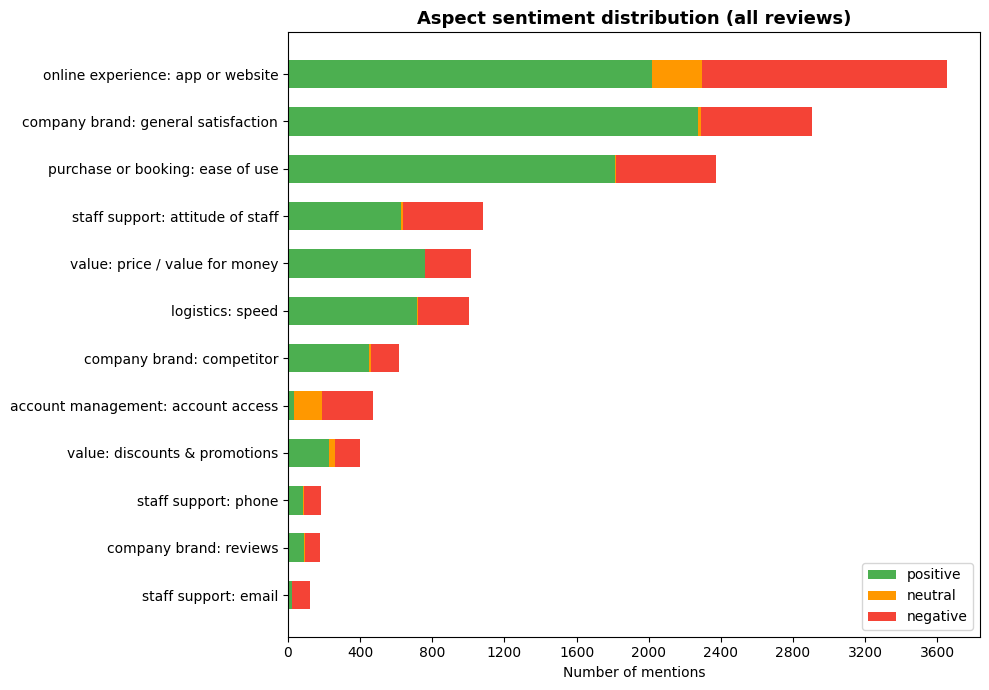

In [8]:
# Stacked horizontal bar chart — count per aspect
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'positive': '#4caf50', 'neutral': '#ff9800', 'negative': '#f44336'}
aspects = pivot.index.tolist()[::-1]   # bottom-to-top order
lefts = np.zeros(len(aspects))

for sentiment in ['positive', 'neutral', 'negative']:
    vals = [pivot.loc[a, sentiment] for a in aspects]
    ax.barh(aspects, vals, left=lefts, color=colors[sentiment], label=sentiment, height=0.6)
    lefts += np.array(vals)

ax.set_xlabel('Number of mentions')
ax.set_title('Aspect sentiment distribution (all reviews)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

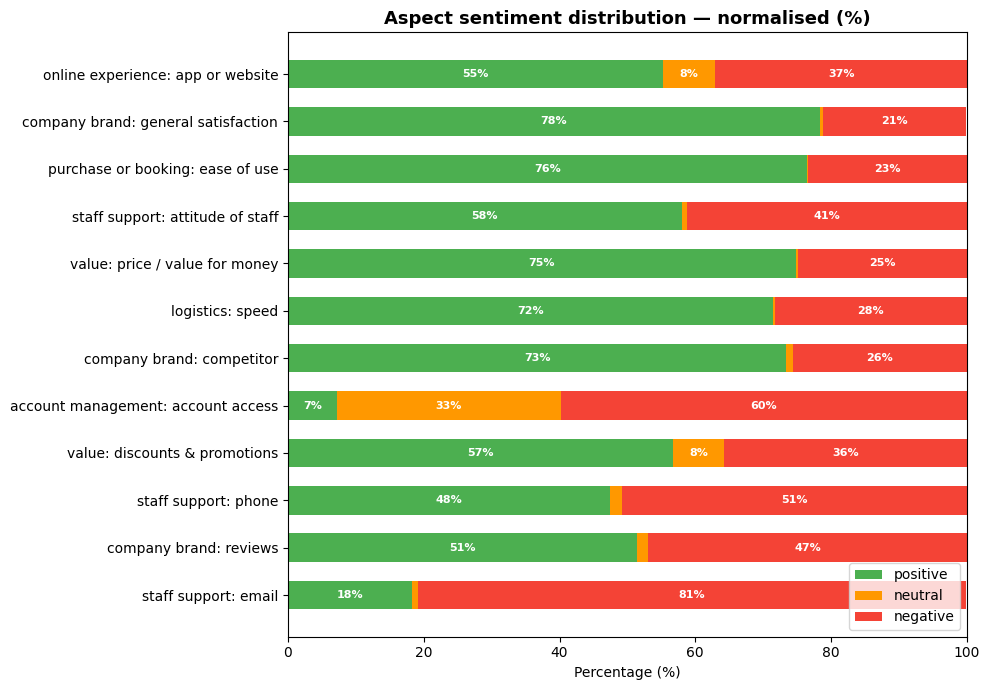

In [9]:
# Stacked horizontal bar chart — percentage per aspect (normalised)
fig, ax = plt.subplots(figsize=(10, 7))

lefts = np.zeros(len(aspects))
for sentiment in ['positive', 'neutral', 'negative']:
    vals = [pivot_pct.loc[a, sentiment] for a in aspects]
    bars = ax.barh(aspects, vals, left=lefts, color=colors[sentiment], label=sentiment, height=0.6)
    for bar, v in zip(bars, vals):
        if v >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold'
            )
    lefts += np.array(vals)

ax.set_xlabel('Percentage (%)')
ax.set_xlim(0, 100)
ax.set_title('Aspect sentiment distribution — normalised (%)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Overall sentiment counts:
sentiment
positive    9122
negative    4366
neutral      510


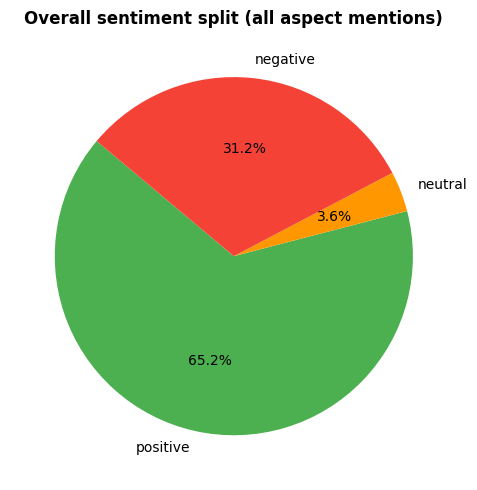

In [10]:
# Overall sentiment distribution across all aspects
overall = df_mentions['sentiment'].value_counts()
print("Overall sentiment counts:")
print(overall.to_string())

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [overall.get('positive', 0), overall.get('neutral', 0), overall.get('negative', 0)],
    labels=['positive', 'neutral', 'negative'],
    colors=[colors['positive'], colors['neutral'], colors['negative']],
    autopct='%1.1f%%', startangle=140
)
ax.set_title('Overall sentiment split (all aspect mentions)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()